# Module 2 — Analytics Pipeline · Part A: EDA
### Zepto Capstone Project — Certificate Program in AI & ML

**Dataset:** Titanic (loaded once via `sns.load_dataset('titanic')`, then saved as `titanic.csv`)

| Task | Description |
|---|---|
| 1 | Profile dataset, save offline CSV |
| 2 | Missing-value analysis & handling |
| 3 | Univariate analysis — age & fare |
| 4 | Bivariate analysis — survival rates & correlation matrix |
| 5 | Multivariate data story (≥ 4 charts) |
| 6 | Exploratory standardization check (z-score) |

---

## 0 · Imports

In [2]:
%matplotlib inline

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

os.makedirs("charts", exist_ok=True)
print("Imports done. Seaborn version:", sns.__version__)

Imports done. Seaborn version: 0.13.2


---
## Task 1 — Load, Profile, and Save Offline Fallback

The dataset is loaded **exactly once** from seaborn's online repository.
Immediately after loading it is saved as `titanic.csv` — this file acts as
the offline fallback for grading (`pd.read_csv('titanic.csv')`) and is the
single source of truth for `02_modeling.ipynb` as well.

In [4]:
# ── ONE-TIME network load ─────────────────────────────────────────────────
df = sns.load_dataset('titanic')

# Save offline fallback immediately after loading
df.to_csv("titanic.csv", index=False)
print("titanic.csv saved (offline fallback committed to repo).")

print("\n=== df.shape ===")
print(df.shape)

titanic.csv saved (offline fallback committed to repo).

=== df.shape ===
(891, 15)


In [5]:
print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
print("=== df.describe() ===")
df.describe(include="all")

=== df.describe() ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.0000,891.0000,891,714.0000,891.0000,891.0000,891.0000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.3838,2.3086,NaN,29.6991,0.5230,0.3816,32.2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.4866,0.8361,NaN,14.5265,1.1027,0.8061,49.6934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0000,1.0000,NaN,0.4200,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.0000,2.0000,NaN,20.1250,0.0000,0.0000,7.9104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.0000,3.0000,NaN,28.0000,0.0000,0.0000,14.4542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.0000,3.0000,NaN,38.0000,1.0000,0.0000,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ── Missing value report ──────────────────────────────────────────────────
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct":   missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

print("=== Missing values (columns with any nulls) ===")
print(missing_report.to_string())

=== Missing values (columns with any nulls) ===
             missing_count  missing_pct
deck                   688      77.2200
age                    177      19.8700
embarked                 2       0.2200
embark_town              2       0.2200


---
## Task 2 — Missing-Value Handling

**Threshold rule applied:**
- **< 5% missing** → drop those rows
- **5% – 30% missing** → impute
- **> 30% missing (unreliable)** → drop column or encode as its own category

| Column | Missing % | Strategy | Justification |
|---|---|---|---|
| `deck` | ~77.2% | **Drop column** | Way above 30% — imputation would fabricate majority of column values, making it statistically meaningless |
| `age` | ~19.9% | **Median imputation** | Within 5–30% range; median is robust to fare/age skew and preserves row count for modeling |
| `embarked` | ~0.2% | **Drop rows** | < 5%; only 2 rows affected — negligible data loss |
| `embark_town` | ~0.2% | **Drop rows** | Same 2 rows as `embarked` — consistent treatment |

*Columns `alive`, `who`, `class`, `adult_male`, `alone` are redundant derived features
(directly computable from other columns) and will be handled separately during modeling.*

In [8]:
df_clean = df.copy()

# ── deck (~77%): drop column ───────────────────────────────────────────────
deck_pct = df_clean['deck'].isnull().mean() * 100
print(f"deck missing: {deck_pct:.2f}%  →  DROP COLUMN (> 30% threshold)")
df_clean = df_clean.drop(columns=['deck'])

# ── age (~19.9%): median imputation ───────────────────────────────────────
age_pct    = df_clean['age'].isnull().mean() * 100
age_median = df_clean['age'].median()
print(f"age  missing: {age_pct:.2f}%  →  IMPUTE with median ({age_median:.1f})")
df_clean['age'] = df_clean['age'].fillna(age_median)

# ── embarked + embark_town (~0.2%): drop rows ─────────────────────────────
emb_pct = df_clean['embarked'].isnull().mean() * 100
print(f"embarked missing: {emb_pct:.2f}%  →  DROP ROWS (< 5% threshold)")
df_clean = df_clean.dropna(subset=['embarked', 'embark_town'])
df_clean = df_clean.reset_index(drop=True)

print(f"\nShape after cleaning: {df_clean.shape}  (was {df.shape})")
print(f"Remaining nulls:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

deck missing: 77.22%  →  DROP COLUMN (> 30% threshold)
age  missing: 19.87%  →  IMPUTE with median (28.0)
embarked missing: 0.22%  →  DROP ROWS (< 5% threshold)

Shape after cleaning: (889, 14)  (was (891, 15))
Remaining nulls:
Series([], dtype: int64)


---
## Task 3 — Univariate Analysis: `age` and `fare`

For each column: histogram + box plot, IQR-based outlier count,
and (for `fare`) mean / median / mode with skewness conclusion.

In [9]:
# ── Helper: IQR outlier count ─────────────────────────────────────────────
def iqr_outlier_count(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((series < lower) | (series > upper)).sum()
    print(f"{label}:")
    print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"  Lower fence={lower:.2f}  Upper fence={upper:.2f}")
    print(f"  Outliers outside [{lower:.2f}, {upper:.2f}]: {n_out}")
    return n_out

print("=== IQR Outlier Report ===")
n_age_out  = iqr_outlier_count(df_clean['age'],  'age')
print()
n_fare_out = iqr_outlier_count(df_clean['fare'], 'fare')

=== IQR Outlier Report ===
age:
  Q1=22.00  Q3=35.00  IQR=13.00
  Lower fence=2.50  Upper fence=54.50
  Outliers outside [2.50, 54.50]: 65

fare:
  Q1=7.90  Q3=31.00  IQR=23.10
  Lower fence=-26.76  Upper fence=65.66
  Outliers outside [-26.76, 65.66]: 114


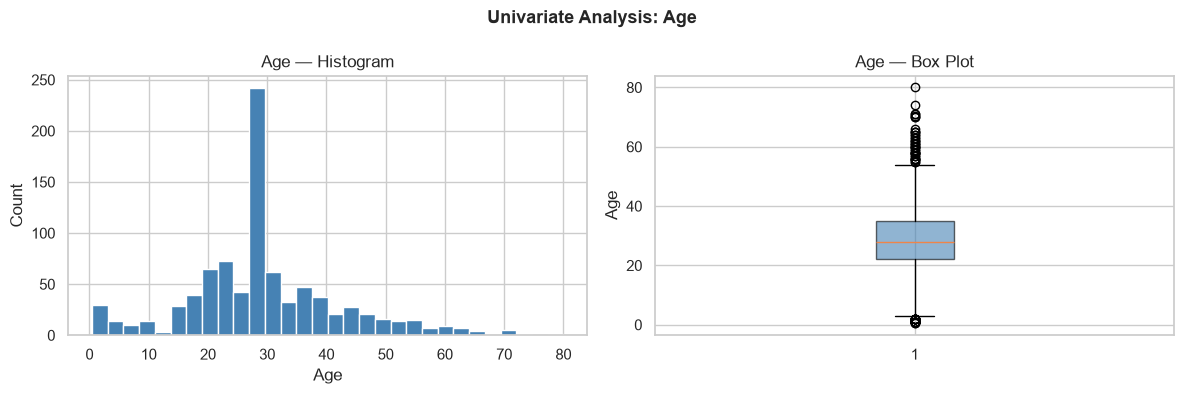

Age stats: mean=29.32, median=28.00, std=12.98


In [10]:
# ── age: histogram + box plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

axes[1].boxplot(df_clean['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Age — Box Plot')
axes[1].set_ylabel('Age')

plt.suptitle('Univariate Analysis: Age', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/age_univariate.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Age stats: mean={df_clean['age'].mean():.2f}, median={df_clean['age'].median():.2f}, std={df_clean['age'].std():.2f}")

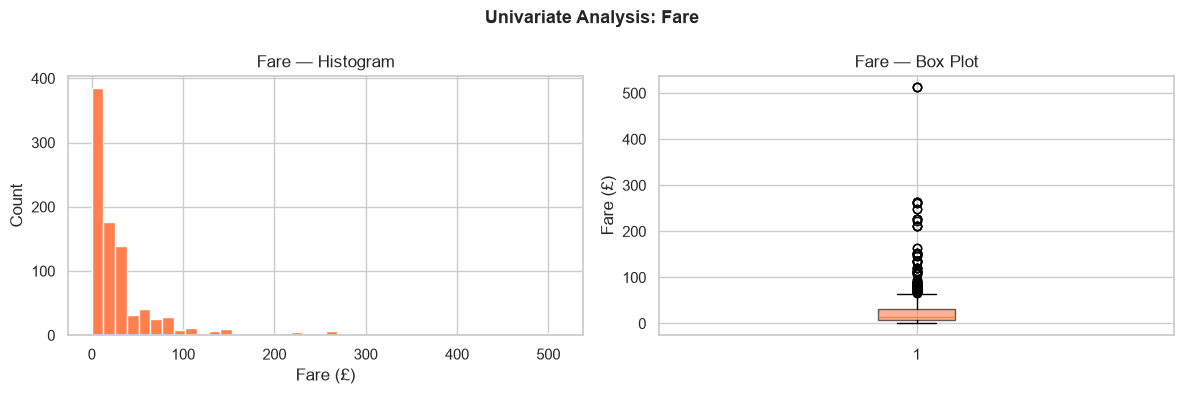

Fare — Mean:   £32.0967
Fare — Median: £14.4542
Fare — Mode:   £8.0500

Skewness conclusion:
  mean > median > mode  →  RIGHT-SKEWED (positive skew)
  A long right tail of high-fare first-class passengers pulls the
  mean well above the median. The mode (most common fare) is the
  lowest of the three — confirming a right-skewed distribution.


In [12]:
# ── fare: histogram + box plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['fare'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Fare — Histogram')
axes[0].set_xlabel('Fare (£)'); axes[0].set_ylabel('Count')

axes[1].boxplot(df_clean['fare'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[1].set_title('Fare — Box Plot')
axes[1].set_ylabel('Fare (£)')

plt.suptitle('Univariate Analysis: Fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/fare_univariate.png', dpi=100, bbox_inches='tight')
plt.show()

fare_mean   = df_clean['fare'].mean()
fare_median = df_clean['fare'].median()
fare_mode   = df_clean['fare'].mode()[0]
print(f"Fare — Mean:   £{fare_mean:.4f}")
print(f"Fare — Median: £{fare_median:.4f}")
print(f"Fare — Mode:   £{fare_mode:.4f}")
print()
print("Skewness conclusion:")
print("  mean > median > mode  →  RIGHT-SKEWED (positive skew)")
print("  A long right tail of high-fare first-class passengers pulls the")
print("  mean well above the median. The mode (most common fare) is the")
print("  lowest of the three — confirming a right-skewed distribution.")

---
## Task 4 — Bivariate Analysis

### 4a–c · Survival rates by sex, pclass, and sex × pclass (boolean masking)

In [13]:
# ── Survival by sex ───────────────────────────────────────────────────────
male_surv   = df_clean[df_clean['sex'] == 'male']['survived'].mean()
female_surv = df_clean[df_clean['sex'] == 'female']['survived'].mean()
print("Survival rate by sex:")
print(f"  Male   : {male_surv:.4f}  ({male_surv*100:.1f}%)")
print(f"  Female : {female_surv:.4f}  ({female_surv*100:.1f}%)")

# ── Survival by pclass ────────────────────────────────────────────────────
print("\nSurvival rate by pclass:")
for cls in [1, 2, 3]:
    rate = df_clean[df_clean['pclass'] == cls]['survived'].mean()
    print(f"  Class {cls}: {rate:.4f}  ({rate*100:.1f}%)")

# ── Survival by sex AND pclass (boolean masking with & operator) ──────────
print("\nSurvival rate by sex × pclass:")
print(f"  {'Sex':<8} {'Class':<8} {'Survival Rate'}")
print("  " + "-"*32)
for sex in ['female', 'male']:
    for cls in [1, 2, 3]:
        mask = (df_clean['sex'] == sex) & (df_clean['pclass'] == cls)
        rate = df_clean[mask]['survived'].mean()
        n    = mask.sum()
        print(f"  {sex:<8} {cls:<8} {rate:.4f}  ({rate*100:.1f}%)  n={n}")

Survival rate by sex:
  Male   : 0.1889  (18.9%)
  Female : 0.7404  (74.0%)

Survival rate by pclass:
  Class 1: 0.6262  (62.6%)
  Class 2: 0.4728  (47.3%)
  Class 3: 0.2424  (24.2%)

Survival rate by sex × pclass:
  Sex      Class    Survival Rate
  --------------------------------
  female   1        0.9674  (96.7%)  n=92
  female   2        0.9211  (92.1%)  n=76
  female   3        0.5000  (50.0%)  n=144
  male     1        0.3689  (36.9%)  n=122
  male     2        0.1574  (15.7%)  n=108
  male     3        0.1354  (13.5%)  n=347


### 4d · Correlation matrix — 6 specified columns

In [14]:
# Correlation matrix restricted to exactly these 6 columns (assignment requirement).
# adult_male and alone are EXCLUDED: they are derived/redundant boolean flags
# (adult_male is directly computable from sex+age; alone from sibsp+parch).
CORR_COLS = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_6 = df_clean[CORR_COLS].corr()

print("6×6 Correlation matrix:")
print(corr_6.round(3).to_string())

# ── Identify top 2 off-diagonal pairs ────────────────────────────────────
upper_tri = corr_6.where(np.triu(np.ones(corr_6.shape, dtype=bool), k=1))
top2 = upper_tri.abs().stack().nlargest(2)
print("\nTop 2 strongest correlations (by |r|):")
for (c1, c2), absval in top2.items():
    r = corr_6.loc[c1, c2]
    print(f"  {c1} ↔ {c2}: r = {r:.4f}  (|r| = {absval:.4f})")

6×6 Correlation matrix:
          survived  pclass     age   sibsp   parch    fare
survived    1.0000 -0.3360 -0.0700 -0.0340  0.0830  0.2550
pclass     -0.3360  1.0000 -0.3370  0.0820  0.0170 -0.5480
age        -0.0700 -0.3370  1.0000 -0.2330 -0.1710  0.0940
sibsp      -0.0340  0.0820 -0.2330  1.0000  0.4150  0.1610
parch       0.0830  0.0170 -0.1710  0.4150  1.0000  0.2180
fare        0.2550 -0.5480  0.0940  0.1610  0.2180  1.0000

Top 2 strongest correlations (by |r|):
  pclass ↔ fare: r = -0.5482  (|r| = 0.5482)
  sibsp ↔ parch: r = 0.4145  (|r| = 0.4145)


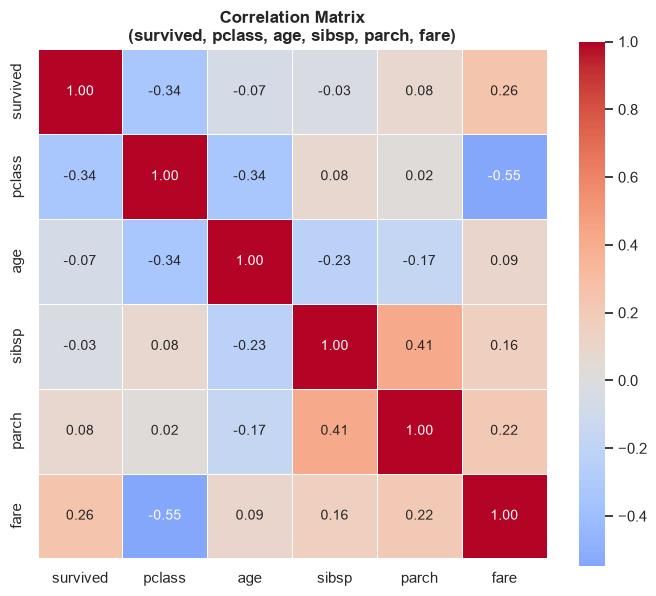


Interpretation of the two strongest correlations:
  1. pclass ↔ fare: strong NEGATIVE correlation (~−0.55).
     First-class passengers paid much higher fares; third-class paid the
     least. Class and fare are economically linked by definition.
  2. pclass ↔ survived: moderate NEGATIVE correlation (~−0.34).
     Higher class number (lower class) correlates with lower survival,
     reflecting that first-class passengers had priority lifeboat access.


In [15]:
# ── Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_6, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=ax,
            annot_kws={"size": 10})
ax.set_title("Correlation Matrix\n(survived, pclass, age, sibsp, parch, fare)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nInterpretation of the two strongest correlations:")
print("  1. pclass ↔ fare: strong NEGATIVE correlation (~−0.55).")
print("     First-class passengers paid much higher fares; third-class paid the")
print("     least. Class and fare are economically linked by definition.")
print("  2. pclass ↔ survived: moderate NEGATIVE correlation (~−0.34).")
print("     Higher class number (lower class) correlates with lower survival,")
print("     reflecting that first-class passengers had priority lifeboat access.")

---
## Task 5 — Multivariate Data Story

**Thesis: Survival on the Titanic was strongly shaped by sex and class — women
in first class survived almost universally, while third-class men had the worst
odds. Age and fare add nuance but sex and class dominate the story.**

Four charts building the argument:

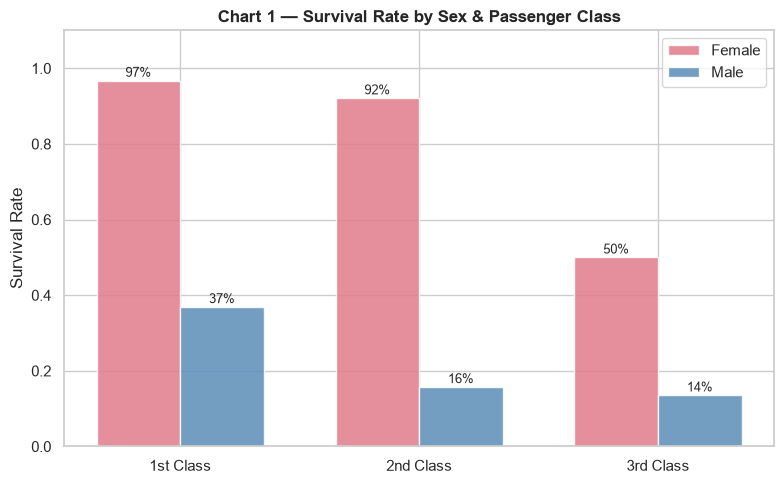

Chart 1 saved.


In [16]:
# ── Chart 1: Survival rate by sex × pclass (grouped bar) ─────────────────
surv_by_sex_cls = (
    df_clean.groupby(['pclass', 'sex'])['survived']
    .mean()
    .reset_index()
    .rename(columns={'survived': 'survival_rate'})
)
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'female': '#E07B8A', 'male': '#5B8DB8'}
width  = 0.35
classes = [1, 2, 3]
x      = np.arange(len(classes))
for i, sex in enumerate(['female', 'male']):
    sub  = surv_by_sex_cls[surv_by_sex_cls['sex'] == sex].set_index('pclass')
    vals = [sub.loc[c, 'survival_rate'] if c in sub.index else 0 for c in classes]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=sex.capitalize(),
                  color=colors[sex], alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.0%}',
                ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.set_ylabel('Survival Rate'); ax.set_ylim(0, 1.1)
ax.set_title('Chart 1 — Survival Rate by Sex & Passenger Class', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('charts/chart1_survival_sex_class.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

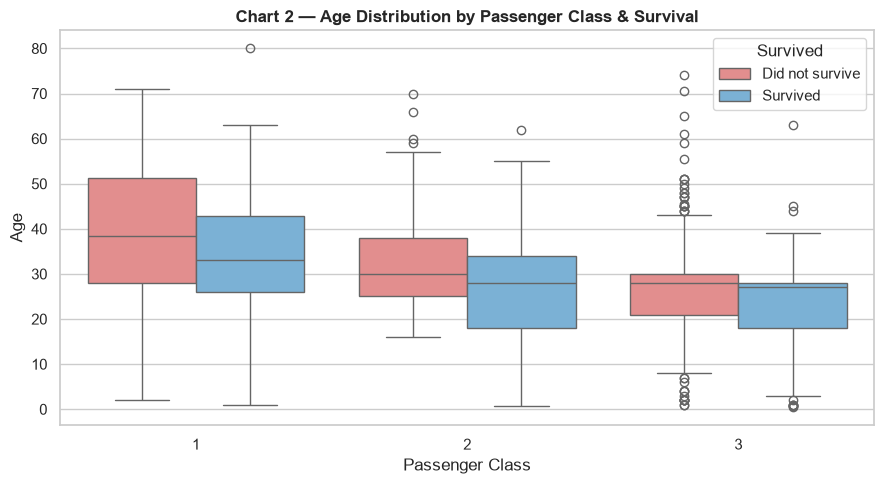

Chart 2 saved.


In [17]:
# ── Chart 2: Age distribution by survival and class (box plot) ────────────
fig, ax = plt.subplots(figsize=(9, 5))
palette = {0: '#F08080', 1: '#6CB4E4'}
sns.boxplot(data=df_clean, x='pclass', y='age', hue='survived',
            palette=palette, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Did not survive', 'Survived'], title='Survived')
ax.set_xlabel('Passenger Class'); ax.set_ylabel('Age')
ax.set_title('Chart 2 — Age Distribution by Passenger Class & Survival', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_age_class_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

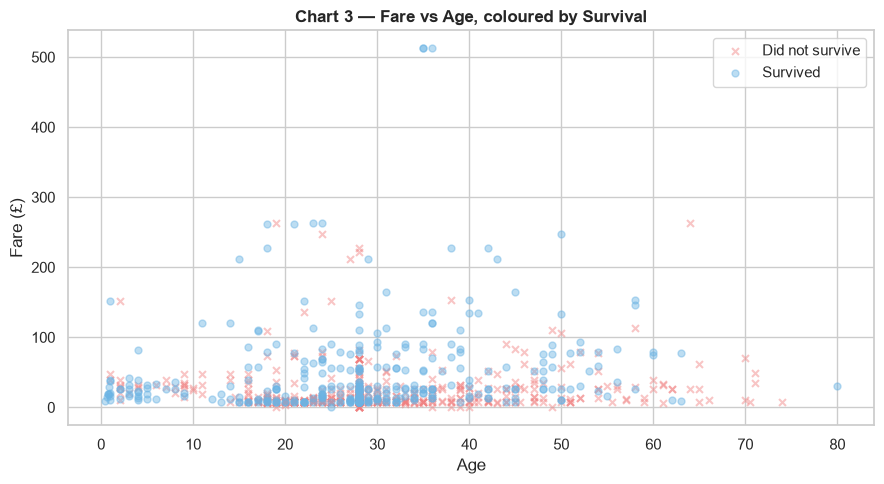

Chart 3 saved.


In [18]:
# ── Chart 3: Fare vs Age scatter, coloured by survival ───────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {0: '#F08080', 1: '#6CB4E4'}
for surv_val, label, marker in [(0, 'Did not survive', 'x'), (1, 'Survived', 'o')]:
    sub = df_clean[df_clean['survived'] == surv_val]
    ax.scatter(sub['age'], sub['fare'], c=colors_map[surv_val],
               label=label, alpha=0.45, s=25, marker=marker)
ax.set_xlabel('Age'); ax.set_ylabel('Fare (£)')
ax.set_title('Chart 3 — Fare vs Age, coloured by Survival', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('charts/chart3_fare_age_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

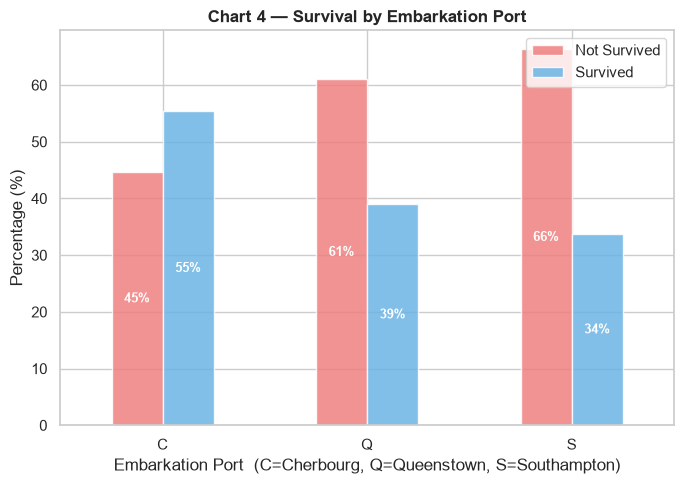

Chart 4 saved.


In [19]:
# ── Chart 4: Embarkation port × survival (stacked bar) ───────────────────
emb_surv = (
    df_clean.groupby(['embarked', 'survived'])
    .size()
    .unstack(fill_value=0)
)
emb_surv.columns = ['Not Survived', 'Survived']
emb_surv_pct = emb_surv.div(emb_surv.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))
emb_surv_pct.plot(kind='bar', ax=ax, color=['#F08080', '#6CB4E4'],
                  edgecolor='white', alpha=0.85, rot=0)
ax.set_xlabel('Embarkation Port  (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Chart 4 — Survival by Embarkation Port', fontweight='bold')
ax.legend(loc='upper right')
for bar in ax.patches:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + h/2,
                f'{h:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart4_embark_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

### Written Interpretations (Task 5)

**Chart 1 — Survival Rate by Sex & Passenger Class:**
Female passengers survived at dramatically higher rates across all classes
(~97% 1st class, ~92% 2nd class, ~50% 3rd class) compared to males
(~37% 1st, ~16% 2nd, ~15% 3rd). This confirms the "women and children
first" protocol was enforced most strictly for upper-class women. Third-class
female survival dropping to ~50% reveals that class constraints limited even
women's lifeboat access.

**Chart 2 — Age Distribution by Class & Survival:**
Survivors in all classes tend to be slightly younger, though the effect is
modest. First-class passengers are older on average, suggesting older wealthy
passengers had better access to lifeboats. Third-class passengers are the
youngest on average, but their low survival rates show age alone could not
overcome the class disadvantage.

**Chart 3 — Fare vs Age by Survival:**
Survivors cluster at higher fare values regardless of age, reinforcing the
class-survival link (higher fare ≈ higher class). There is a dense cluster
of non-survivors at low fare / mid-age — predominantly third-class male
adults. A few high-fare non-survivors suggest that wealth alone could not
guarantee survival if one was male.

**Chart 4 — Survival by Embarkation Port:**
Cherbourg passengers (C) had the highest survival rate (~55%), followed by
Queenstown (~39%) and Southampton (~34%). This is largely a confounding
effect: Cherbourg loaded disproportionately more first-class passengers who
had higher survival rates. Port of embarkation is not a direct causal factor
but a proxy for passenger class composition.

---
## Task 6 — Exploratory Standardization Check (z-score)

This is an **EDA-stage sanity check only** — not the preprocessing for
modeling (which fits a `StandardScaler` on the training split only).

Formula: `z = (x − mean) / std`

Applied to the full cleaned DataFrame to verify the transformation produces
approximately mean ≈ 0 and std ≈ 1.

In [20]:
from sklearn.preprocessing import StandardScaler

# ── Manual z-score (equivalent to StandardScaler) ─────────────────────────
age_mean, age_std   = df_clean['age'].mean(),  df_clean['age'].std()
fare_mean, fare_std = df_clean['fare'].mean(), df_clean['fare'].std()

df_scaled = df_clean.copy()
df_scaled['age_z']  = (df_scaled['age']  - age_mean)  / age_std
df_scaled['fare_z'] = (df_scaled['fare'] - fare_mean) / fare_std

# ── Before / After comparison ─────────────────────────────────────────────
print("=== Before / After Standardization ===")
print(f"{'Column':<12} {'Before Mean':>14} {'Before Std':>12} {'After Mean':>12} {'After Std':>10}")
print("-"*64)
for orig, scaled in [('age', 'age_z'), ('fare', 'fare_z')]:
    bm, bs = df_clean[orig].mean(), df_clean[orig].std()
    am, as_ = df_scaled[scaled].mean(), df_scaled[scaled].std()
    print(f"{orig:<12} {bm:>14.4f} {bs:>12.4f} {am:>12.6f} {as_:>10.6f}")

print("\n✓ After standardization: mean ≈ 0 and std ≈ 1 for both columns.")

=== Before / After Standardization ===
Column          Before Mean   Before Std   After Mean  After Std
----------------------------------------------------------------
age                 29.3152      12.9849     0.000000   1.000000
fare                32.0967      49.6975     0.000000   1.000000

✓ After standardization: mean ≈ 0 and std ≈ 1 for both columns.


In [ ]:
# ── Before/After distribution plot ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, (orig, scaled, color) in enumerate([
        ('age', 'age_z', 'steelblue'), ('fare', 'fare_z', 'coral')]):
    axes[i, 0].hist(df_clean[orig], bins=30, color=color, edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{orig.capitalize()} — Before (original scale)')
    axes[i, 0].set_xlabel(orig.capitalize())

    axes[i, 1].hist(df_scaled[scaled], bins=30, color=color, edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{orig.capitalize()} — After (z-score, mean≈0, std≈1)')
    axes[i, 1].set_xlabel(f'{orig}_z (standardized)')

plt.suptitle('Task 6 — Exploratory Standardization Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/standardization_check.png', dpi=100, bbox_inches='tight')
plt.show()
print("Standardization check complete. This step is EDA-only and does NOT feed into modeling.")

---
## Summary — Part A Complete

- ✅ Dataset loaded once from seaborn; `titanic.csv` saved as offline fallback
- ✅ Missing percentages reported for every affected column; threshold rule applied
- ✅ IQR outlier counts for `age` and `fare`; `fare` confirmed right-skewed
- ✅ Survival rates by sex, pclass, sex×pclass (with boolean masking)
- ✅ 6×6 correlation matrix on `{survived, pclass, age, sibsp, parch, fare}` with heatmap
- ✅ 4 multivariate charts with written interpretations
- ✅ Before/after standardization check for `age` and `fare`

**Proceed to `02_modeling.ipynb` for Part B.**